   Simulation    p_mean  p_median  p_random  p_selected selected_method
0           1  0.127810  0.108132  0.338594    0.108132          median
1           2  0.088611  0.075654  0.117496    0.075654          median
2           3  0.765983  0.607763  0.758404    0.607763          median
3           4  0.058247  0.086458  0.031902    0.031902          random
4           5  0.868292  0.949099  0.607839    0.607839          random
5           6  0.043764  0.150731  0.121850    0.043764            mean
6           7  0.786341  0.973348  0.463319    0.463319          random
7           8  0.723729  0.519035  0.383465    0.383465          random
8           9  0.573961  0.525265  0.664930    0.525265          median
9          10  0.297693  0.298597  0.318141    0.297693            mean

Podiel signifikantných výsledkov:
P-hacking (selected): 0.23


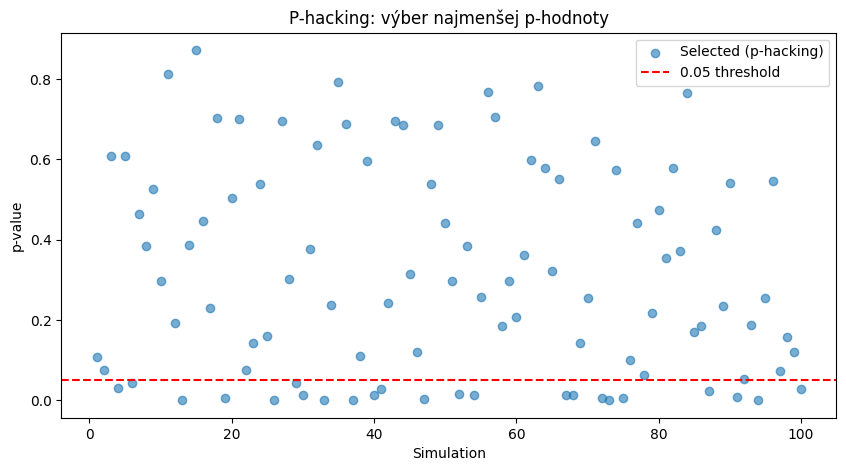

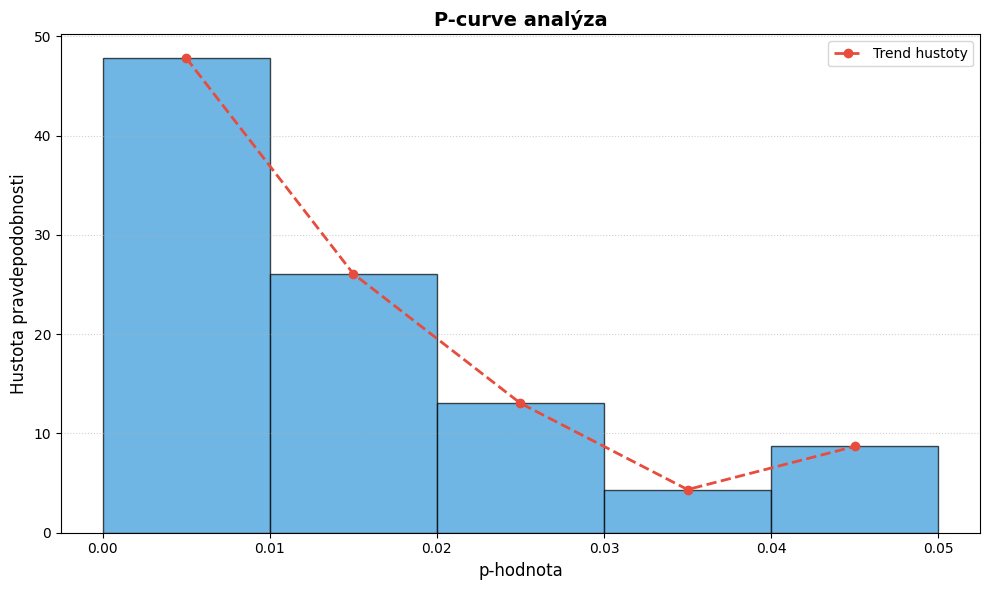

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import sys
import os
sys.path.append(os.path.abspath(".."))
import settings

# Načítanie súborov 
def load_file(file_path):
    return pd.read_sas(file_path, format='xport')

def merge_files(file1, file2):
    return pd.merge(file1, file2[['SEQN','RIDAGEYR','RIAGENDR']], on='SEQN', how='left')

bmx = load_file(settings.bmx_path)
demo = load_file(settings.demo_path)
data = merge_files(bmx, demo)

# premapovanie pohlavia na text
data['gender_label'] = data['RIAGENDR'].map({1: "Men", 2: "Women"})

# Parametre simulácie
dependent_var = 'BMXBMI'
sample_size = 100 
missing_frac = 0.2 # umelo vlozene percento chybajucich hodnot
n_sim = 100 

# Výsledky 
results = []

# Simulácia 
for sim in range(n_sim):
    # vyberie sa nahodna vzorka muzov a zien
    sample = data.groupby('gender_label').sample(sample_size, random_state=sim)

    men = sample[sample['gender_label']=='Men'][dependent_var].copy()
    women = sample[sample['gender_label']=='Women'][dependent_var].copy()

    # 20% nahodnych indexov v muzskej a zenskej populacii nastavená na NaN
    men_nan_idx = men.sample(frac=missing_frac, random_state=sim).index
    women_nan_idx = women.sample(frac=missing_frac, random_state=sim).index

    men.loc[men_nan_idx] = np.nan
    women.loc[women_nan_idx] = np.nan

    men_mean = men.copy()
    women_mean = women.copy()

    # doplnenie chýbajúcich hodnôt priemerom
    men_mean.fillna(men.mean(), inplace=True)
    women_mean.fillna(women.mean(), inplace=True)

     # t-test
    if men_mean.notna().sum() > 1 and women_mean.notna().sum() > 1:
        _, p_fair = stats.ttest_ind(men_mean, women_mean)
    else:
        p_fair = np.nan

    # všetky imputácie
    p_values = {}

    # priemer
    men_imp = men.copy()
    women_imp = women.copy()
    men_imp.fillna(men.mean(), inplace=True)
    women_imp.fillna(women.mean(), inplace=True)

    if men_imp.notna().sum() > 1 and women_imp.notna().sum() > 1:
        _, p_values['mean'] = stats.ttest_ind(men_imp, women_imp)
    else:
        p_values['mean'] = np.nan

    # median
    men_imp = men.copy()
    women_imp = women.copy()
    men_imp.fillna(men.median(), inplace=True)
    women_imp.fillna(women.median(), inplace=True)

    if men_imp.notna().sum() > 1 and women_imp.notna().sum() > 1:
        _, p_values['median'] = stats.ttest_ind(men_imp, women_imp)
    else:
        p_values['median'] = np.nan

    # random 
    men_imp = men.copy()
    women_imp = women.copy()

    men_nonan = men.dropna().to_numpy()
    women_nonan = women.dropna().to_numpy()

    # men
    if len(men_nan_idx) > 0:
        if len(men_nonan) > 0:
            men_imp.loc[men_nan_idx] = np.random.choice(
                men_nonan, size=len(men_nan_idx), replace=True
            )
        else:
            men_imp.fillna(men.mean(), inplace=True)

    # women
    if len(women_nan_idx) > 0:
        if len(women_nonan) > 0:
            women_imp.loc[women_nan_idx] = np.random.choice(
                women_nonan, size=len(women_nan_idx), replace=True
            )
        else:
            women_imp.fillna(women.mean(), inplace=True)

    men_imp.fillna(men_imp.mean(), inplace=True)
    women_imp.fillna(women_imp.mean(), inplace=True)

    if men_imp.notna().sum() > 1 and women_imp.notna().sum() > 1:
        _, p_values['random'] = stats.ttest_ind(men_imp, women_imp)
    else:
        p_values['random'] = np.nan

    # výber najmenšieho p 
    valid_p = {k: v for k, v in p_values.items() if not np.isnan(v)}

    if len(valid_p) > 0:
        selected_method = min(valid_p, key=valid_p.get)
        p_selected = valid_p[selected_method]
    else:
        selected_method = None
        p_selected = np.nan

    # ulozenie
    results.append({
        "Simulation": sim+1,
        "p_mean": p_values['mean'],
        "p_median": p_values['median'],
        "p_random": p_values['random'],
        "p_selected": p_selected,
        "selected_method": selected_method
    })

#tabulka
df = pd.DataFrame(results)

df.to_csv("phacking_imputacia.csv", index=False)

# vypis
print(df.head(10))

# kvantifikacia
phacking_rate = (df['p_selected'] < 0.05).mean()

print("\nPodiel signifikantných výsledkov:")
print(f"P-hacking (selected): {phacking_rate:.2f}")

# graf
plt.figure(figsize=(10,5))

plt.scatter(df['Simulation'], df['p_selected'], alpha=0.6, label='Selected (p-hacking)')

plt.axhline(0.05, linestyle='--', color='red', label='0.05 threshold')

plt.xlabel('Simulation')
plt.ylabel('p-value')
plt.title('P-hacking: výber najmenšej p-hodnoty')
plt.legend()
plt.show()

# p-curve analýza

sig_p = df[df['p_selected'] < 0.05]['p_selected'].dropna()

if len(sig_p) > 0:
    plt.figure(figsize=(10, 6))
    
    # Histogram hustoty 
    counts, bins, _ = plt.hist(sig_p, bins=5, range=(0, 0.05), 
                               color='#3498db', edgecolor='black', alpha=0.7, density=True)
    
    # Vykreslenie trendovej čiary 
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    plt.plot(bin_centers, counts, color='#e74c3c', marker='o', linestyle='--', linewidth=2, label='Trend hustoty')

    # Formátovanie grafu
    plt.title('P-curve analýza', fontsize=14, fontweight='bold')
    plt.xlabel('p-hodnota', fontsize=12)
    plt.ylabel('Hustota pravdepodobnosti', fontsize=12)
    plt.xticks(np.arange(0, 0.06, 0.01))
    plt.grid(axis='y', linestyle=':', alpha=0.6)
    plt.legend()

    # Automatická interpretácia do grafu
    if counts[-1] > counts[0]:
        plt.text(0.01, max(counts)*0.9, "Detegovaný p-hacking\n(Ľavostranné zošikmenie)", 
                 color='red', fontsize=10, fontweight='bold', bbox=dict(facecolor='white', alpha=0.8))

    plt.tight_layout()
    plt.savefig("pcurve_imputacia.png", dpi=300)
    plt.show()

    low_p = len(sig_p[sig_p < 0.01])
    high_p = len(sig_p[(sig_p >= 0.04) & (sig_p < 0.05)])